In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("Mall_Customers.csv")
X  = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.50495142 0.49504858]


In [6]:
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

C:\Users\Krishna\anaconda3\envs\ai_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Krishna\anaconda3\envs\ai_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Krishna\anaconda3\envs\ai_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Krishna\anaconda3\envs\ai_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

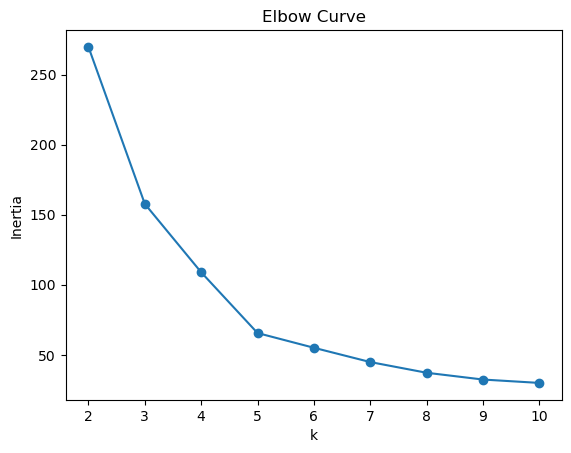

In [7]:
plt.plot(k_range, inertias, marker='o')
plt.xlabel("k"); plt.ylabel("Inertia")
plt.title("Elbow Curve"); plt.show()

In [8]:
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

C:\Users\Krishna\anaconda3\envs\ai_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
sil = silhouette_score(X_scaled, labels)
print(f"Silhouette Score (k={k_opt}): {sil:.4f}")

Silhouette Score (k=5): 0.5547


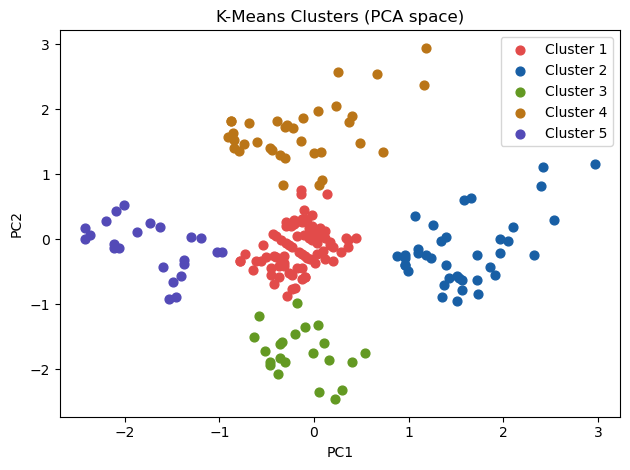

In [10]:
colors = ['#E24B4A','#185FA5','#639922','#BA7517','#534AB7']
for i in range(k_opt):
    mask = labels == i
    plt.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[i], label=f"Cluster {i+1}", s=40)
plt.title("K-Means Clusters (PCA space)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(); plt.tight_layout(); plt.show()